In [15]:
mandatory_data = [
    'Date',
    'Departure station',
    'Arrival station',
]

def drop_wrong_line(df, mandatory_data):
    df = df.dropna(subset=mandatory_data)
    df = df.drop_duplicates()
    return df

drop_wrong_line : 
USE : delete all line with null value in mandatory data + delete duplicates line
PARAMS : df(dataset) and mendatory_data(list of mandatory data for use the line)
RETURN : df (dataset "cleaned" with no usable line)

In [16]:
cols_to_num = [
    'Average journey time', 
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

cols_to_string = [
    'Service',
    'Departure station',
    'Arrival station',
    'Cancellation comments',
    'Departure delay comments',
    'Arrival delay comments'
]

def convert_to_type(df, cols_to_num, cols_to_string):
    for col_num in cols_to_num:
        df[col_num] = df[col_num].astype(str)
        df[col_num] = df[col_num].str.replace(',', '.')
        df[col_num] = df[col_num].str.replace(' min', '')
        df[col_num] = df[col_num].str.replace('%', '')
        df[col_num] = pd.to_numeric(df[col_num], errors='coerce')
    for col_str in cols_to_string:
        df[col_str] = df[col_str].astype(str)
    df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m', errors='coerce')
    return df

convert_to_type : 
USE : convert all columns with the great type (str, float, datetime)
PARAMS : df(dataset), cols_to_num(list of cols to convert in float) and cols_to_string(list of cols to convert in string)
RETURN : df (dataset "cleaned" with great type)

In [17]:
def new_cols(df):
    df['Month'] = df['Date'].dt.month
    df['Year'] = df['Date'].dt.year
    df['delay_category'] = df['Average delay of all trains at arrival'].round()
    return df

new_cols : 
USE : create new cols (month, year and delay_category)
PARAMS : df(dataset)
RETURN : df (dataset with new cols)

In [18]:
null_val_to_zero = [
    'Number of scheduled trains',
    'Number of cancelled trains',
    'Number of trains delayed at departure',
    'Average delay of late trains at departure',
    'Average delay of all trains at departure',
    'Number of trains delayed at arrival',
    'Average delay of late trains at arrival',
    'Average delay of all trains at arrival',
    'Number of trains delayed > 15min',
    'Average delay of trains > 15min (if competing with flights)',
    'Number of trains delayed > 30min',
    'Number of trains delayed > 60min',
    'Pct delay due to external causes',
    'Pct delay due to infrastructure',
    'Pct delay due to traffic management',
    'Pct delay due to rolling stock',
    'Pct delay due to station management and equipment reuse',
    'Pct delay due to passenger handling (crowding, disabled persons, connections)'
]

def handle_null_value(df):
    df[cols_to_string] = df[cols_to_string].fillna("None")
    df[null_val_to_zero] = df[null_val_to_zero].fillna(0)
    median_val = df['Average journey time'].median()
    df['Average journey time'] = df['Average journey time'].fillna(median_val)
    return df

handle_null_value : 
USE : convert all null value to the "good value" (None, 0 or median_val)
PARAMS : df(dataset)
RETURN : df (dataset "cleaned" with good null value)

In [19]:
import pandas as pd

def read_csv(filepath: str) -> pd.DataFrame:
    df = pd.read_csv(filepath, sep=";")
    df = convert_to_type(df, cols_to_num, cols_to_string)
    df = drop_wrong_line(df, mandatory_data)
    df = handle_null_value(df)
    df['Date'] = df['Date'].dt.to_period('M')
    df = new_cols(df)
    return df

filepath = "dataset.csv"
output_file = "cleaned_dataset.csv"

df = read_csv(filepath)
df.to_csv(output_file, index=False)

df.info()

<class 'pandas.DataFrame'>
Index: 11400 entries, 0 to 12060
Data columns (total 29 columns):
 #   Column                                                                         Non-Null Count  Dtype    
---  ------                                                                         --------------  -----    
 0   Date                                                                           11400 non-null  period[M]
 1   Service                                                                        11400 non-null  str      
 2   Departure station                                                              11400 non-null  str      
 3   Arrival station                                                                11400 non-null  str      
 4   Average journey time                                                           11400 non-null  float64  
 5   Number of scheduled trains                                                     11400 non-null  float64  
 6   Number of cancelled tr

read_csv : 
USE : read a csv and return a cleaned csv
PARAMS : filepath (name of the basic dataset csv)
RETURN : df (dataset "cleaned")

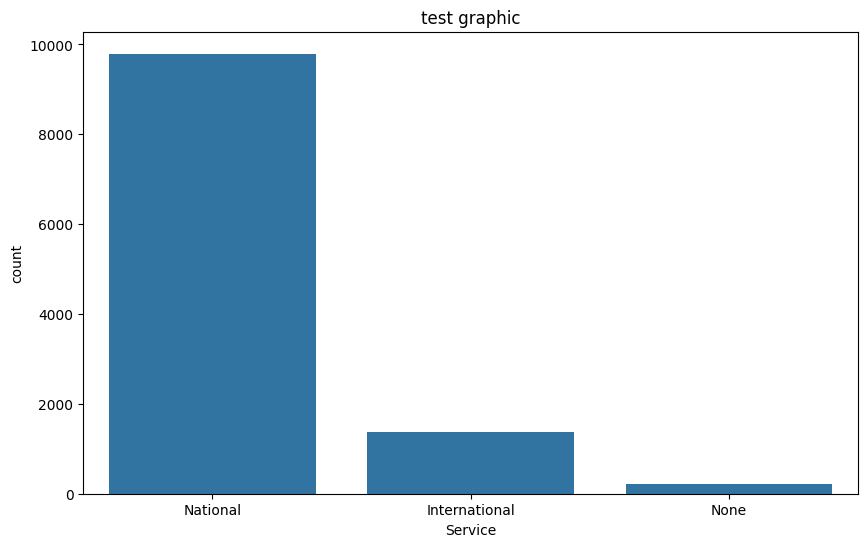

In [20]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.countplot(data=df, x='Service')
plt.title("test graphic")
plt.show()

test graphic
USE : print a test graphic (bar graph)
PARAMS : df (dataset)
RETURN : bar graph of "Service"

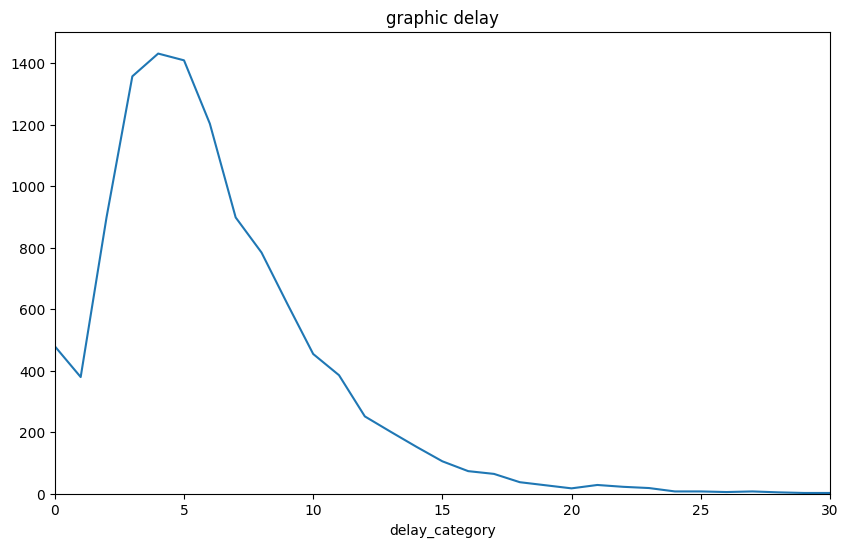

In [21]:
counts = df['delay_category'].value_counts()

plt.figure(figsize=(10, 6))
sns.lineplot(x=counts.index, y=counts.values)
plt.xlim(0, 30)
plt.ylim(0)
plt.title("graphic delay")
plt.show()

graphic delay
USE : print a graphic delay (line graph)
PARAMS : df (dataset)
RETURN : line graph of "delay"